How many of the different morphology classes are in the full Y1 TF sample?  In the main cosmology sample?

In [43]:
import numpy as np

from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import astropy.constants as const
import astropy.units as u

import matplotlib.pyplot as plt

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/')
# sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from z_CMB_convert import convert_z_frame
from help_functions import profile_histogram

In [44]:
h = 1
H0 = 100*h*u.km/u.s/u.Mpc

c = const.c.to('km/s')

# Read in TF catalog

In [2]:
gals = Table.read('/Users/kdouglass/Documents/Research/data/DESI/Y1/DESI-DR1_TF_pv_cat_v15.fits')

In [3]:
gals[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,V_0p4R26,V_0p4R26_ERR,PHOTSYS,MORPHTYPE_AI,JOHN_VI,Z_DESI_CMB,G_MAG_SB26_CORR,R_MAG_SB26_CORR,Z_MAG_SB26_CORR,G_MAG_SB26_ERR_CORR,R_MAG_SB26_ERR_CORR,Z_MAG_SB26_ERR_CORR,MU_ZCMB,R_ABSMAG_SB26,MU_ZCMB_ERR,R_ABSMAG_SB26_ERR,DWARF,GOOD_MORPH,GOOD_VEL,R_ABSMAG_SB26_TF,R_ABSMAG_SB26_TF_ERR,R_ABSMAG_SB26_TF_ERR_STAT,R_ABSMAG_SB26_TF_ERR_SYS,MU_TF,MU_TF_ERR,LOGDIST,LOGDIST_ERR,MAIN
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,mag,,mag,,,,,,,,,,,mag,mag,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,bytes1,bytes10,bytes6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,bool
38.0,SGA-2020 38,SDSSJ140638.88+393138.1,3558705,211.66194,39.5272341,S?,81.63,0.35318315,0.37757218,0.08108376,24.72948,18.361,False,LEDA-20181114,12,SDSSJ140638.88+393138.1,1,True,211.66194,39.5272341,0.35318315,2115p395,211.66203166014844,39.52724032794356,0.41757938,SB26,82.21093,0.41431504,211.6619547015994,39.52729608884245,8.520181,5.252184,4.0750155,3.3951538,3.3006833,4.4037066,5.5453897,6.693271,7.8023033,8.999919,10.213078,11.41192,12.527382,19.246052,18.406073,17.931826,18.841032,18.092857,17.659027,18.566164,17.886087,17.47688,18.383362,17.749825,17.355968,18.261652,17.655558,17.284552,18.168955,17.588947,17.231817,18.101948,17.547142,17.20673,18.055267,17.516266,17.18719,18.023865,1

# Histogram of different morphologies

In [8]:
# Full catalog
classes_all, class_counts_all = np.unique(gals['MORPHTYPE_AI'], return_counts=True)

# Just the main cosmology sample
classes_main, class_counts_main = np.unique(gals['MORPHTYPE_AI'][gals['MAIN']], return_counts=True)

# Just the "dwarfs"
classes_dwarf, class_counts_dwarf = np.unique(gals['MORPHTYPE_AI'][~gals['MAIN']], return_counts=True)

In [13]:
# Replace the missing class with "Unknown"
classes_all[0] = 'Unknown'
classes_main[0] = 'Unknown'
classes_dwarf[0] = 'Unknown'

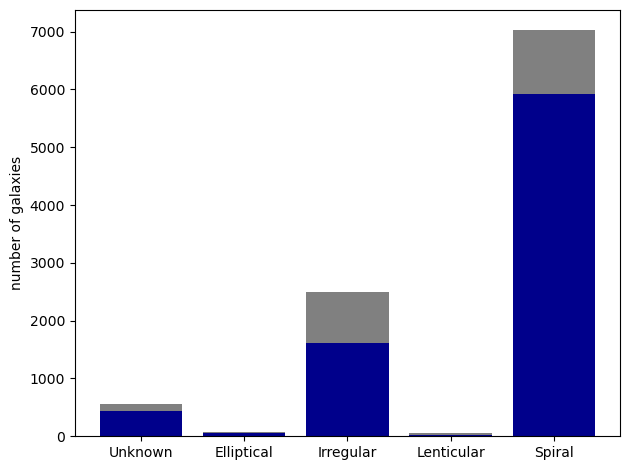

In [14]:
plt.figure(tight_layout=True)

# Full catalog
# plt.bar(classes_all, class_counts_all)

# Main cosmology sample
plt.bar(classes_main, class_counts_main, facecolor='darkblue')

# "Dwarf" sample
plt.bar(classes_dwarf, class_counts_dwarf, bottom=class_counts_main, facecolor='gray')

plt.ylabel('number of galaxies');

## Make a small table of the counts and percentages

In [15]:
class_counts = Table()

class_counts['Sample'] = ['All', 'Main', 'Dwarf']

for label in classes_all:

    i_all = classes_all == label
    i_main = classes_main == label
    i_dwarf = classes_dwarf == label

    class_counts[label] = [class_counts_all[i_all], 
                           class_counts_main[i_main], 
                           class_counts_dwarf[i_dwarf]]

In [16]:
class_counts

Sample,Unknown,Elliptical,Irregular,Lenticular,Spiral
str5,int64[1],int64[1],int64[1],int64[1],int64[1]
All,560,70,2496,50,7024
Main,438,55,1609,24,5922
Dwarf,122,15,887,26,1102


In [17]:
np.sum(class_counts_all)

np.int64(10200)

In [18]:
np.sum(class_counts_main)

np.int64(8048)

In [19]:
np.sum(class_counts_dwarf)

np.int64(2152)

# What does the distribution in $\eta$ look like for each of the morphological classes?

In [21]:
spiral_idx = gals['MORPHTYPE_AI'] == 'Spiral'
irregular_idx = gals['MORPHTYPE_AI'] == 'Irregular'
lenticular_idx = gals['MORPHTYPE_AI'] == 'Lenticular'
elliptical_idx = gals['MORPHTYPE_AI'] == 'Elliptical'

spiral = gals[spiral_idx]
irregular = gals[irregular_idx]
lenticular = gals[lenticular_idx]
elliptical = gals[elliptical_idx]
unknown = gals[~spiral_idx & ~irregular_idx & ~lenticular_idx & ~elliptical_idx]

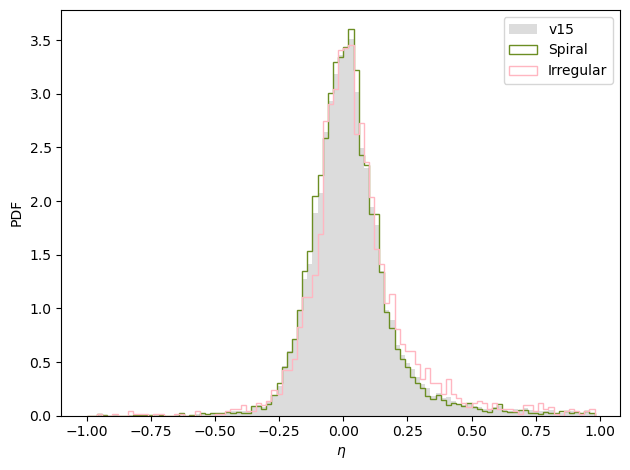

In [34]:
plt.figure(tight_layout=True)

eta_bins = np.arange(-1, 1, 0.02)

plt.hist(gals['LOGDIST'], bins=eta_bins, facecolor='gainsboro', label='v15', density=True)
plt.hist(spiral['LOGDIST'], bins=eta_bins, color='olivedrab', label='Spiral', histtype='step', density=True)
plt.hist(irregular['LOGDIST'], bins=eta_bins, color='lightpink', label='Irregular', histtype='step', density=True)

plt.legend()

plt.xlabel('$\eta$')
# plt.ylabel('number of galaxies');
plt.ylabel('PDF');

In [29]:
print('v15:      ', np.mean(gals['LOGDIST'][gals['MAIN']]), np.std(gals['LOGDIST'][gals['MAIN']]))
print('Spiral:   ', np.mean(spiral['LOGDIST'][spiral['MAIN']]), np.std(spiral['LOGDIST'][spiral['MAIN']]))
print('Irregular:', np.mean(irregular['LOGDIST'][irregular['MAIN']]), np.std(irregular['LOGDIST'][irregular['MAIN']]))

v15:       0.013581360371158755 0.12129574079968358
Spiral:    0.01177969881379677 0.12230539456361914
Irregular: 0.02467071531953128 0.11428359013123421


In [41]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)

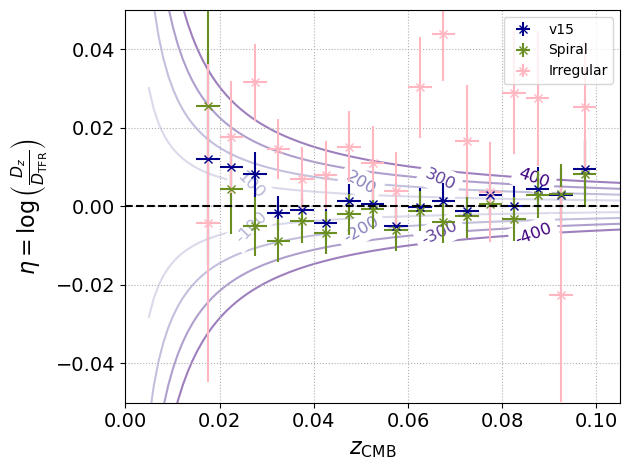

In [50]:
plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
_dz = 0.5*np.diff(_zbins)
_zc = 0.5*(_zbins[1:] + _zbins[:-1])

# Plot the original catalog
N, y_avg, y_std = profile_histogram(gals['Z_DESI_CMB'][gals['MAIN']], 
                                    gals['LOGDIST'][gals['MAIN']], 
                                    _zbins, 
                                    weights=gals['LOGDIST_ERR'][gals['MAIN']]**-2, 
                                    weighted=True)
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', 
             color='darkblue', 
             label='v15')

# Plot the spirals
N, y_avg, y_std = profile_histogram(spiral['Z_DESI_CMB'][spiral['MAIN']], 
                                    spiral['LOGDIST'][spiral['MAIN']], 
                                    _zbins, 
                                    weights=spiral['LOGDIST_ERR'][spiral['MAIN']]**-2, 
                                    weighted=True)
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', 
             color='olivedrab', 
             label='Spiral')

# Plot the irregulars
_zbins_irr = np.arange(0, 0.105, 0.01)
_dz_irr = 0.5*np.diff(_zbins_irr)
_zc_irr = 0.5*(_zbins_irr[1:] + _zbins_irr[:-1])

N, y_avg, y_std = profile_histogram(irregular['Z_DESI_CMB'][irregular['MAIN']], 
                                    irregular['LOGDIST'][irregular['MAIN']], 
                                    _zbins, 
                                    weights=irregular['LOGDIST_ERR'][irregular['MAIN']]**-2, 
                                    weighted=True)
plt.errorbar(_zc, y_avg, xerr=_dz, yerr=y_std, fmt='x', 
             color='lightpink', 
             label='Irregular')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Purples(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.05, 0.05))
# plt.ylim((-0.13, 0.13))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

plt.legend();